## tools

In [ ]:
from langchain_core.tools import tool
from dotenv import load_dotenv 

load_dotenv()

@tool
def clone_repo(url:str):
    """
    
    """

    return "x"

@tool
def navigate_to_folder(path:str):
    """
    """


@tool
def extract_repo_details():
    """
    
    """
    # Use Repopack 
    # Insert into a rag
    return "x"




## Create simple processor agent

#### Helper methods

In [12]:
from langchain_core.messages import HumanMessage
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

def show_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

def create_initial_message(text="Hi!"):
    """Creates a message instance with the given text."""
    
    return {"messages": [format_message(text)]}


def format_message(text="Hi! My name is Bob.", MessageClass: type = HumanMessage):
    """Creates a single message instance."""
    return MessageClass(content=text)


def create_model(model_id = "gpt-5-nano", local = False):
    if local:
        model = ChatOllama(
            model=model_id,
            temperature=0,
            )
    else:
        model = ChatOpenAI(
            model=model_id,
            timeout=30
            )

    return model

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_ollama import ChatOllama
from dotenv import load_dotenv 

load_dotenv()

model = create_model()
agent = create_agent(
    model=model,
    tools=[]
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
print(result)



### Create LLM agent with chat

================================ Human Message =================================

hi, my name is bob
================================== Ai Message ==================================

Nice to meet you, Bob! How can I help today? If you tell me what you’re working on or what you’d like to do, I’ll tailor my responses to fit.
================================ Human Message =================================

hi, my name is bob
================================== Ai Message ==================================

Nice to meet you, Bob! How can I help today? Here are a few things I can do:

- Answer questions or explain topics
- Help plan, draft, or edit documents or emails
- Brainstorm ideas or solve problems
- Learn or practice something new
- Help with code or tech issues

Tell me your goal or what you’d like to work on, and I’ll tailor my response. What would you like to start with?
================================ Human Message =================================

write a short poem about cats


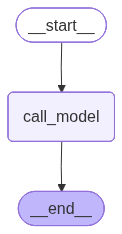

In [ ]:
from langchain_core.messages.utils import (trim_messages, count_tokens_approximately)
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, MessagesState

from langgraph.checkpoint.memory import InMemorySaver


def setup_graph(model_name = "openai:gpt-5-nano", max_tokens = 358):
    model = create_model()
    agent = create_agent(
        model=model,
        tools=[]
    )
    agent = init_chat_model(model_name)

    def call_model(state: MessagesState):
        messages = trim_messages(
            state["messages"],
            strategy="last",
            token_counter=count_tokens_approximately,
            max_tokens=max_tokens,
            start_on="human",
            end_on=("human", "tool"),
        )
        response = agent.invoke(messages)
        return {"messages": [response]}

    checkpointer = InMemorySaver()
    builder = StateGraph(MessagesState)
    builder.add_node(call_model)
    builder.add_edge(START, "call_model")
    graph = builder.compile(checkpointer=checkpointer)
    return graph


graph = setup_graph()
default_config = {"configurable": {"thread_id": "1"}}

def simple_chat(graph, msg:str, config = default_config):
    return graph.invoke({"messages" : msg}, config)



show_example = True
if show_example:
    simple_chat(graph, "hi, my name is bob",)
    simple_chat(graph, "write a short poem about cats")
    simple_chat(graph, "now do the same but for dogs")
    final_response = simple_chat(graph, "what's my name?")


    for message in final_response["messages"]:
        message.pretty_print()

    show_graph(graph)
    graph.get_state(default_config)


## Setup RAG

### Setup RAG with software architecture knowledge